In [2]:
import bz2
import shutil

# This extracts the bz2 file directly using Python
with bz2.BZ2File('train.ft.txt.bz2', 'rb') as f_in:
    with open('train.ft.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Extraction complete!")

Extraction complete!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read file line by line instead of as CSV
with open('train.ft.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Each line looks like: "__label__2 This product is great"
# Split only on FIRST space to separate label from review
data = [line.strip().split(' ', 1) for line in lines if line.strip()]

# Create dataframe
df = pd.DataFrame(data, columns=['label', 'review'])

# Take 10,000 samples
df = df.sample(10000, random_state=42)

# Convert labels: __label__1 = Negative = 0, __label__2 = Positive = 1
df['sentiment'] = df['label'].apply(lambda x: 1 if '__label__2' in x else 0)

print(df.head())
print("\nShape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

              label                                             review  \
2079998  __label__1  Expensive Junk: This product consists of a pie...   
1443106  __label__1  Toast too dark: Even on the lowest setting, th...   
3463669  __label__2  Excellent imagery...dumbed down story: I enjoy...   
2914699  __label__1  Are we pretending everyone is married?: The au...   
1603231  __label__1  Not worth your time: Might as well just use a ...   

         sentiment  
2079998          0  
1443106          0  
3463669          1  
2914699          0  
1603231          0  

Shape: (10000, 3)

Sentiment Distribution:
sentiment
1    5046
0    4954
Name: count, dtype: int64


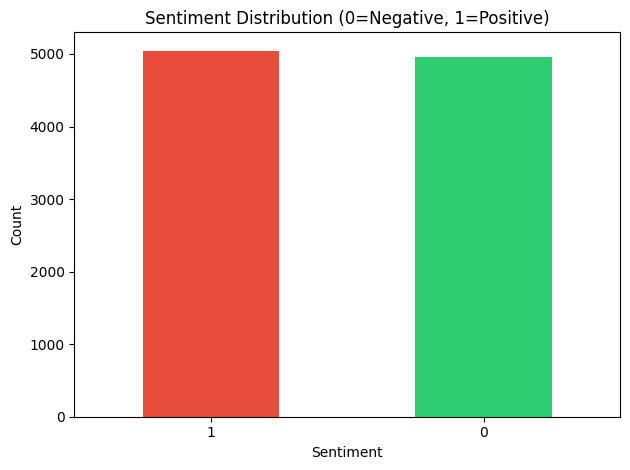

Average review length by sentiment:
sentiment
0    81.280178
1    74.315894
Name: review_length, dtype: float64


ValueError: np.str_('steelbl') is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

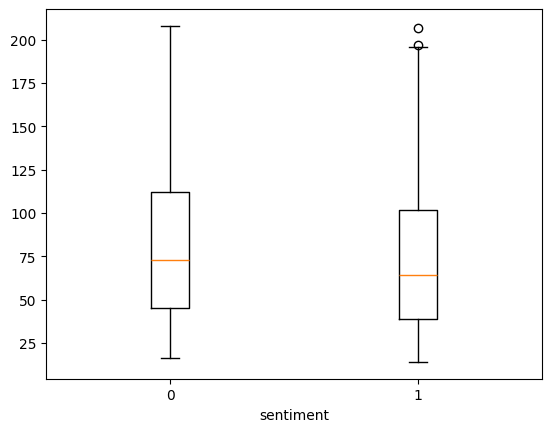

In [5]:
import os
os.makedirs('screenshots', exist_ok=True)

# Plot 1 — Sentiment Distribution
df['sentiment'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Sentiment Distribution (0=Negative, 1=Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('screenshots/distribution.png')
plt.show()

# Plot 2 — Review Length Analysis
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
print("Average review length by sentiment:")
print(df.groupby('sentiment')['review_length'].mean())

df.boxplot(column='review_length', by='sentiment', color='steelblue')
plt.title('Review Length by Sentiment')
plt.suptitle('')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Word Count')
plt.tight_layout()
plt.savefig('screenshots/review_length.png')
plt.show()

In [6]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Clean text function
def clean_text(text):
    text = text.lower()                    # lowercase everything
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation & numbers
    return text

df['clean_review'] = df['review'].apply(clean_text)

# Show before and after cleaning
print("ORIGINAL:")
print(df['review'].iloc[0])
print("\nCLEANED:")
print(df['clean_review'].iloc[0])

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

print("\nMatrix shape:", X.shape)
print("Each review is now represented as", X.shape[1], "numbers")

ORIGINAL:
Expensive Junk: This product consists of a piece of thin flexible insulating material, adhesive backed velcro and white electrical tape.Problems:1. Instructions are three pictures with little more information.2. Velcro was all crumpled as received and was stronger than the adhesive. When i tried to disengage the velcro both pieces came off and the paint from the ceiling.3. White electrical tape was horrible... cheap, narrow and it fell off in less than 1 hour.4. The price is a ripoff.I am building my own which is easier to use, cheaper, more attractive, and higher r-value. I am surprised Amazon even lists this junk.

CLEANED:
expensive junk this product consists of a piece of thin flexible insulating material adhesive backed velcro and white electrical tapeproblems instructions are three pictures with little more information velcro was all crumpled as received and was stronger than the adhesive when i tried to disengage the velcro both pieces came off and the paint from the c

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Train and evaluate all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(max_iter=1000)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"Accuracy: {acc:.2%}")
    print(classification_report(y_test, preds, target_names=['Negative','Positive']))

Training samples: 8000
Testing samples: 2000

Logistic Regression
Accuracy: 83.50%
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83       982
    Positive       0.83      0.85      0.84      1018

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000


Naive Bayes
Accuracy: 80.60%
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       982
    Positive       0.80      0.82      0.81      1018

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000


SVM
Accuracy: 81.85%
              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81       982
    Positive       0.81      0.84      0.83      1018

    accuracy                           0.82    

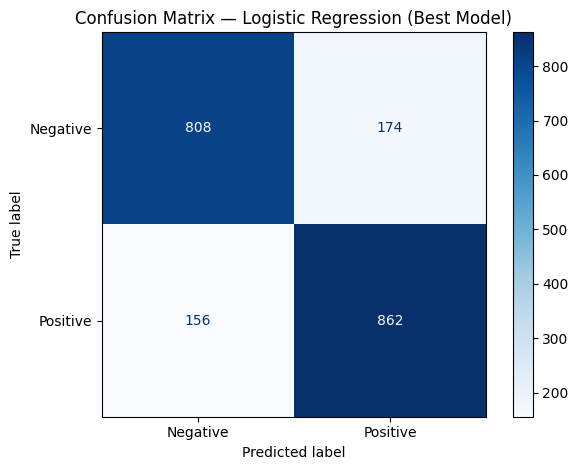


Reading the matrix:
Correctly predicted Negative: 808
Correctly predicted Positive: 862
Wrong predictions total: 330


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use best model — Logistic Regression
best_preds = results['Logistic Regression']['preds']

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Negative', 'Positive'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression (Best Model)')
plt.tight_layout()
plt.savefig('screenshots/confusion_matrix.png')
plt.show()

print("\nReading the matrix:")
print(f"Correctly predicted Negative: {cm[0][0]}")
print(f"Correctly predicted Positive: {cm[1][1]}")
print(f"Wrong predictions total: {cm[0][1] + cm[1][0]}")